###Step 1: Load and Inspect the Data

IMPORT LIBERARIES 

In [2]:
#IMPORT LIBERARIES 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn  as sns 


In [3]:
df = pd.read_csv("oil_gas_equipment_failure.csv")
df.head(10)

,timestamp,equipment_id,equipment_type,vibration_mms,temperature_c,pressure_psi,rpm,oil_flow_rate,current_draw_a,hours_since_maintenance,failure_label
0,2023-01-01 09:00:00,EQ-018,Generator,5.098,84.92,462.53,1449.4,143.90,43.19,418,0
1,2023-01-01 13:00:00,EQ-015,Pipeline,1.712,76.18,426.89,1516.0,123.74,44.74,65,0
2,2023-01-02 01:00:00,EQ-012,Valve,3.132,79.32,468.07,1503.0,124.38,41.90,320,0
3,2023-01-02 18:00:00,EQ-001,Pipeline,13.300,101.85,339.79,819.9,62.76,67.30,524,1
4,2023-01-03 12:00:00,EQ-012,Valve,2.315,74.56,443.17,1500.1,120.87,52.47,161,0
5,2023-01-03 12:00:00,EQ-014,Compressor,2.259,82.06,439.22,1484.8,117.84,43.19,375,0
6,2023-01-03 16:00:00,EQ-015,Pipeline,3.465,73.62,418.74,1460.2,129.31,47.03,378,0
7,2023-01-03 23:00:00,EQ-012,Valve,3.675,70.79,401.29,1534.2,111.85,45.53,492,0
8,2023-01-04 04:00:00,EQ-013,Generator,3.345,70.32,448.66,1498.7,123.85,43.41,488,0
9,2023-01-04 04:00:00,EQ-012,Valve,4.052,77.12,453.25,1608.1,113.83,44.78,27,0


In [4]:

df.shape

(1550, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1550 entries, 0 to 1549
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                1550 non-null   str    
 1   equipment_id             1550 non-null   str    
 2   equipment_type           1550 non-null   str    
 3   vibration_mms            1502 non-null   float64
 4   temperature_c            1508 non-null   float64
 5   pressure_psi             1504 non-null   float64
 6   rpm                      1550 non-null   float64
 7   oil_flow_rate            1506 non-null   float64
 8   current_draw_a           1550 non-null   float64
 9   hours_since_maintenance  1550 non-null   int64  
 10  failure_label            1550 non-null   int64  
dtypes: float64(6), int64(2), str(3)
memory usage: 133.3 KB


Step 2: Summary Statistics

In [6]:
df.describe()  # equipment failed averages 12%, wide variation between min and max indicate presence of outliers 

,vibration_mms,temperature_c,pressure_psi,rpm,oil_flow_rate,current_draw_a,hours_since_maintenance,failure_label
count,1502.000000,1508.000000,1504.000000,1550.000000,1506.000000,1550.000000,1550.000000,1550.000000
mean,4.675564,80.188375,431.561908,1420.721355,113.146388,49.309555,316.823871,0.129032
std,3.213642,14.515078,55.633970,211.274336,21.232311,12.025625,239.985949,0.335344
min,1.137000,60.230000,179.260000,510.900000,13.190000,34.590000,0.000000,0.000000
25%,3.085250,72.460000,430.542500,1444.625000,109.342500,43.310000,140.000000,0.000000
50%,3.709000,76.020000,447.010000,1487.900000,118.460000,45.400000,287.000000,0.000000
75%,4.404500,80.455000,462.175000,1525.700000,125.585000,48.250000,423.000000,0.000000
max,19.596000,140.430000,506.910000,1647.200000,152.600000,98.690000,1190.000000,1.000000


In [7]:
df.columns  

Index(['timestamp', 'equipment_id', 'equipment_type', 'vibration_mms',
       'temperature_c', 'pressure_psi', 'rpm', 'oil_flow_rate',
       'current_draw_a', 'hours_since_maintenance', 'failure_label'],
      dtype='str')

In [8]:
#count missing values 
df.isnull().sum()  

timestamp                   0
equipment_id                0
equipment_type              0
vibration_mms              48
temperature_c              42
pressure_psi               46
rpm                         0
oil_flow_rate              44
current_draw_a              0
hours_since_maintenance     0
failure_label               0
dtype: int64

 Step 3: Distribution Analysis

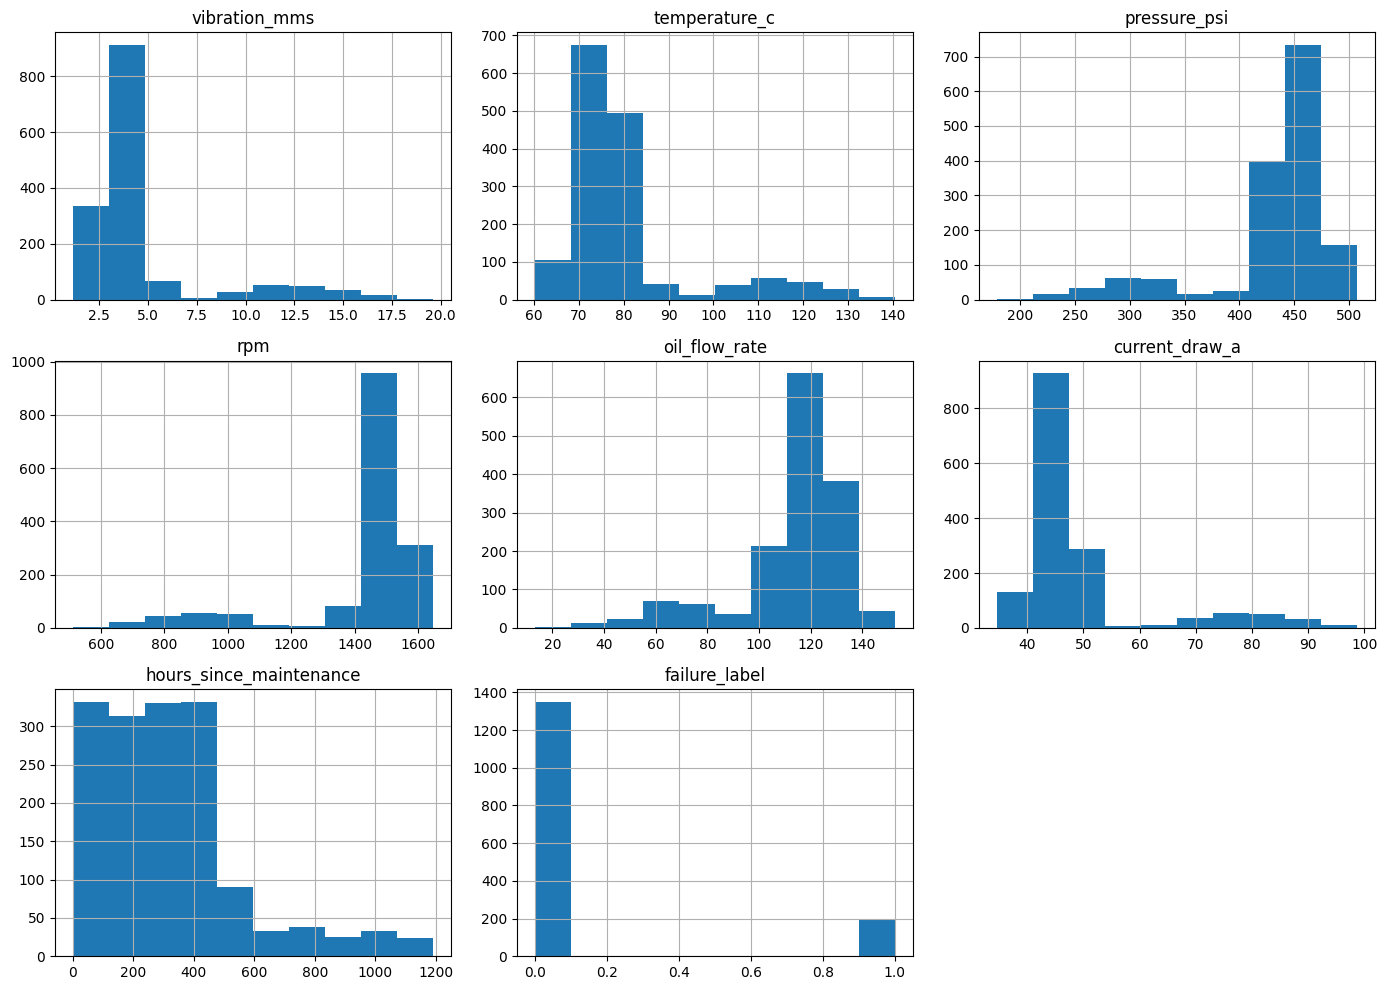

In [11]:
df.hist(bins=10, figsize=(14, 10))
plt.tight_layout()
plt.show()

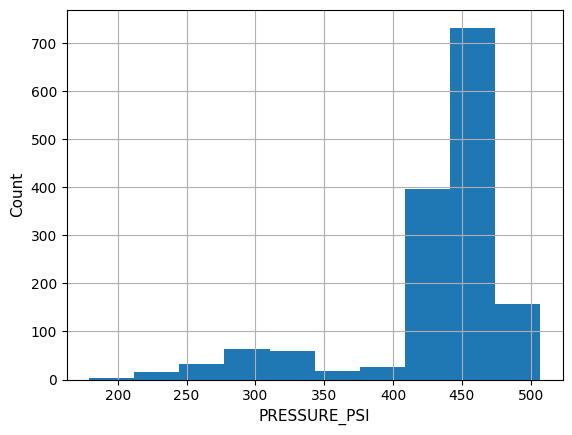

In [12]:
df["pressure_psi"].hist(bins=10)
plt.xlabel("PRESSURE_PSI", fontsize=11)
plt.ylabel('Count', fontsize=11) 
plt.show()


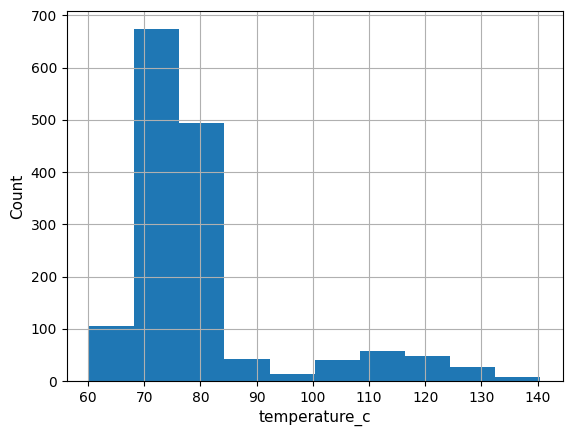

In [13]:
df["temperature_c"].hist(bins=10)  
plt.xlabel("temperature_c", fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.show()


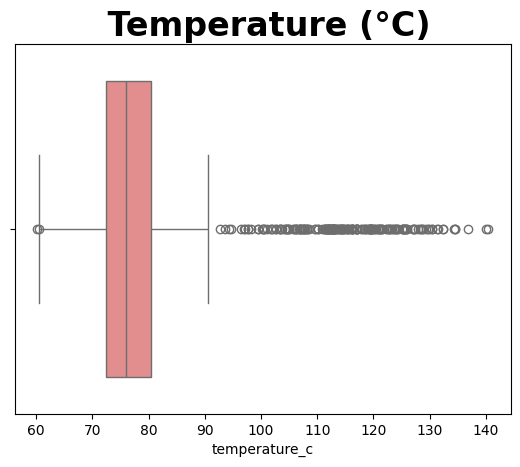

In [14]:
sns.boxplot(x=df["temperature_c"], color="lightcoral")
plt.title(" Temperature (°C)", fontsize=24, fontweight="bold")
plt.show()

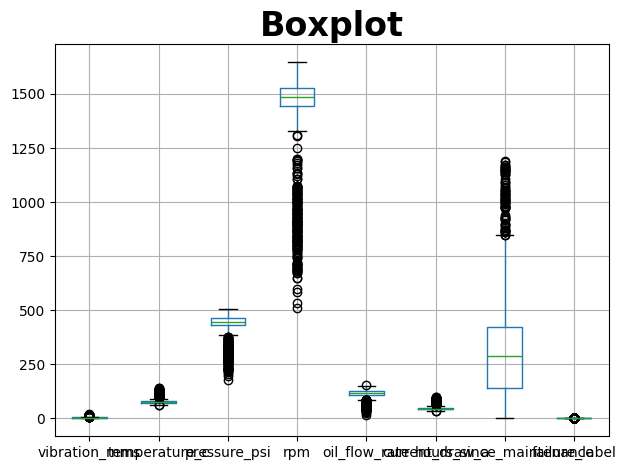

In [15]:
df.boxplot()  
plt.title("Boxplot", fontsize=24, fontweight="bold"  )
plt.tight_layout()
plt.show()

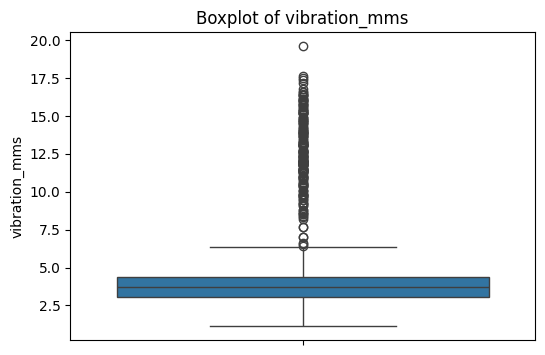

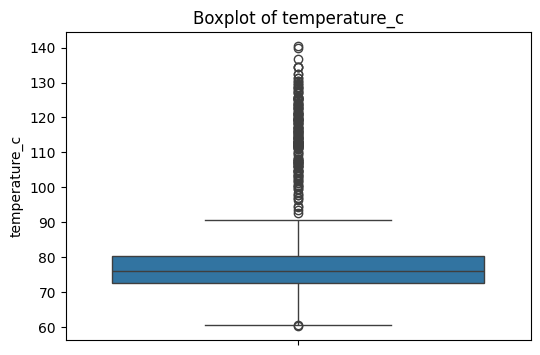

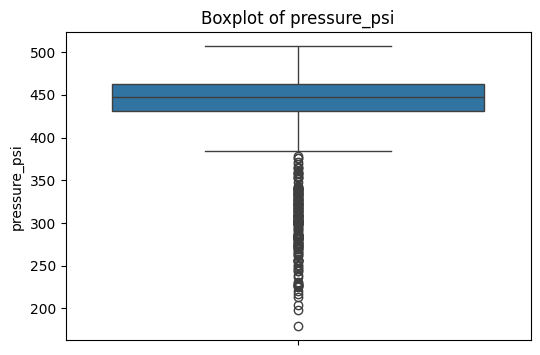

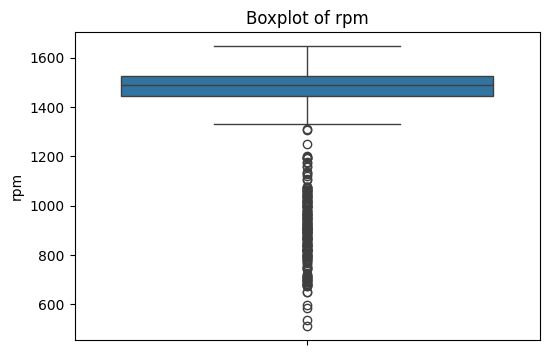

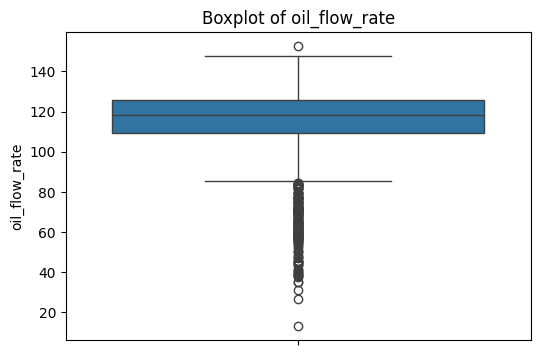

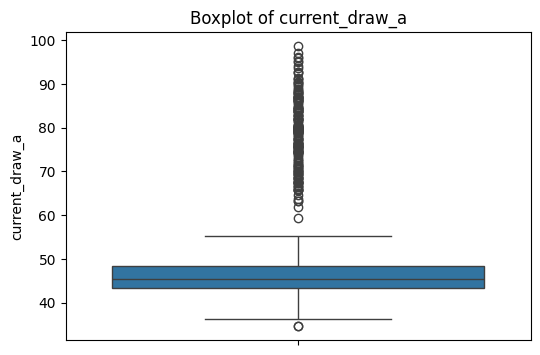

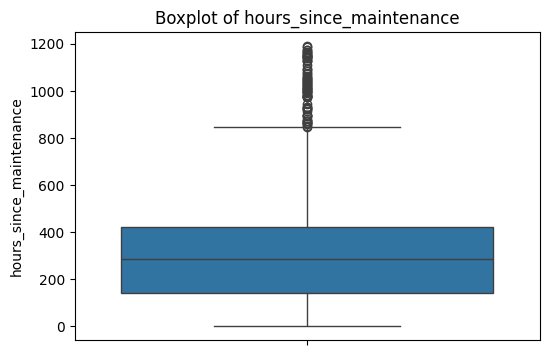

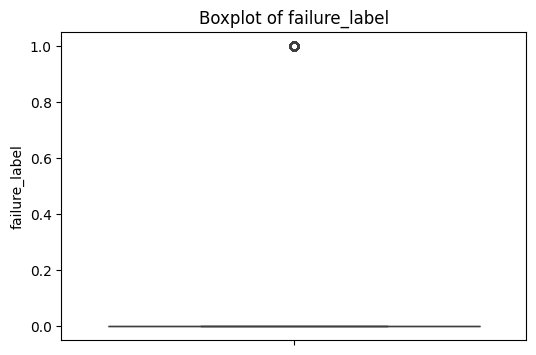

In [16]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns #the nature of the boxplots indicate presence of outliers #Feature scaling is very important to remove the impact of this outliers.

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

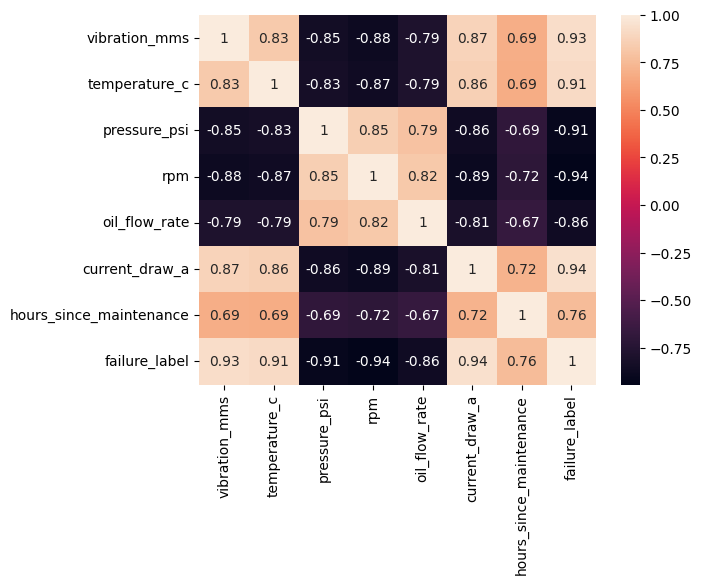

In [17]:
corr = df.corr(numeric_only=True) # failure label shows strong correlation with 1.current_draw_a 2.vibration_mms 2.temperature and hours_since_ maintainance *which means that risk of equipment failure is very high at these points 
sns.heatmap(corr, annot=True)
plt.show()
# Lower RPM, lower pressure, and lower oil flow are strongly associated with failure conditions. because of the low corr with failure_label

STEP 5

In [18]:
failure_counts = df['failure_label'].value_counts()
failure_percent = df['failure_label'].value_counts(normalize=True) * 100

print("Failure Counts:")
print(failure_counts)   # failure occur 12% of the times

print("\nFailure Percentages:")
print(failure_percent)

Failure Counts:
failure_label
0    1350
1     200
Name: count, dtype: int64

Failure Percentages:
failure_label
0    87.096774
1    12.903226
Name: proportion, dtype: float64


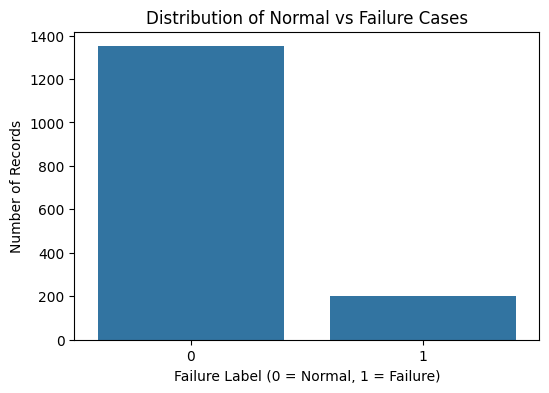

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='failure_label')
plt.title('Distribution of Normal vs Failure Cases')
plt.xlabel('Failure Label (0 = Normal, 1 = Failure)')
plt.ylabel('Number of Records')
plt.show()

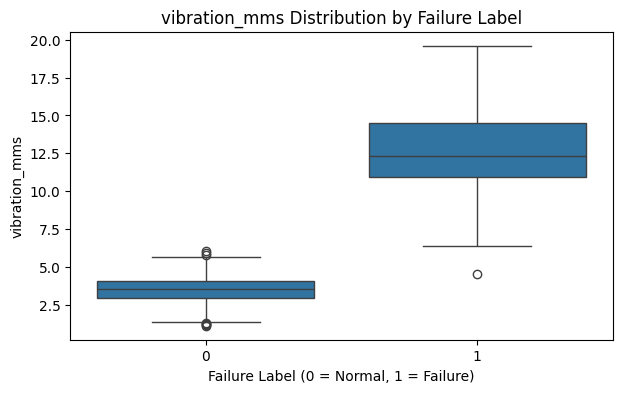

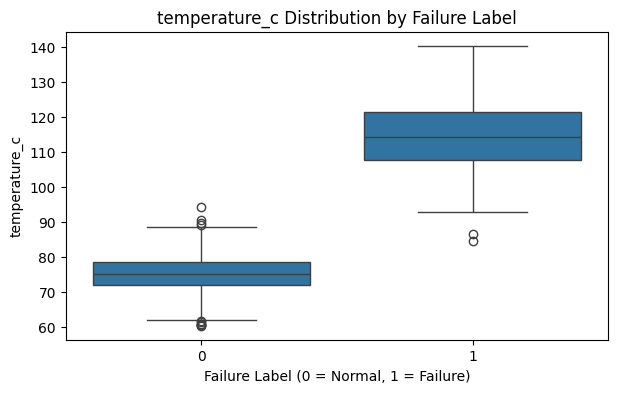

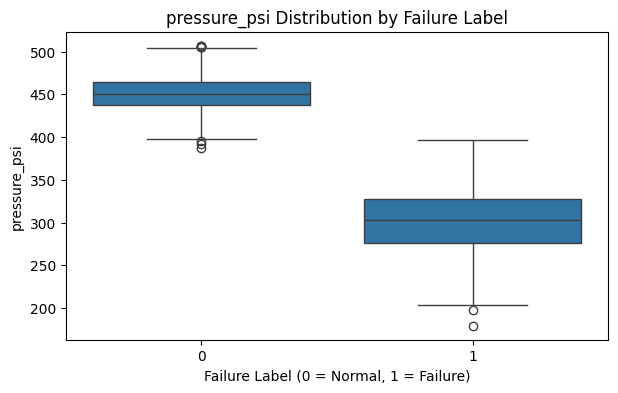

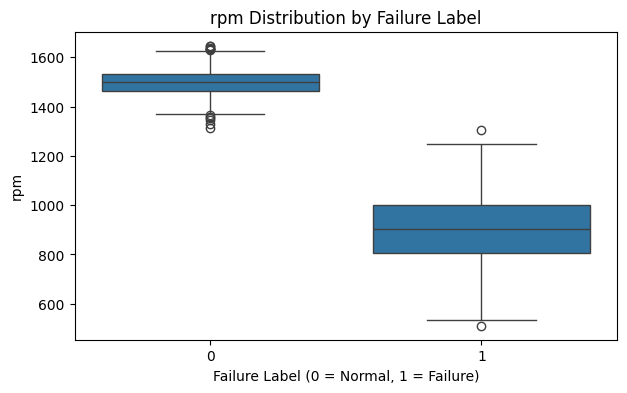

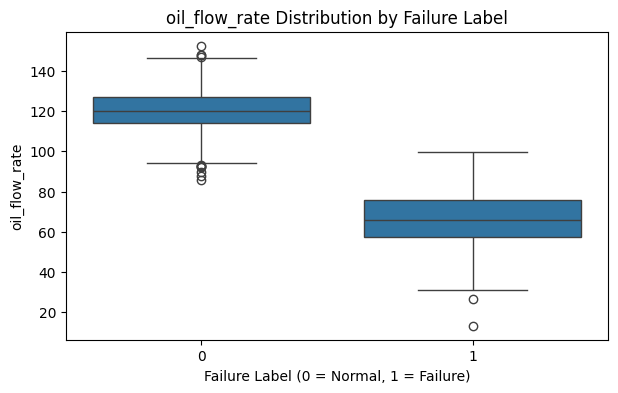

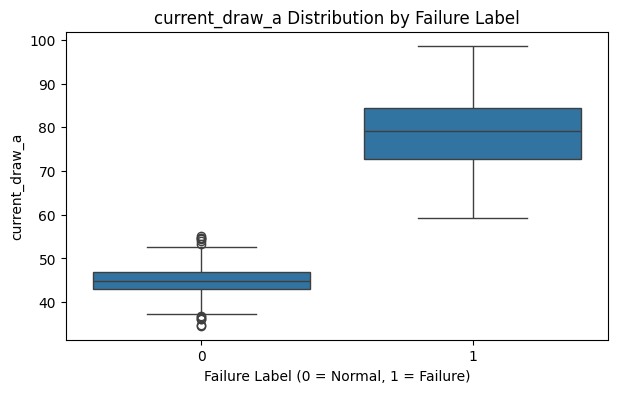

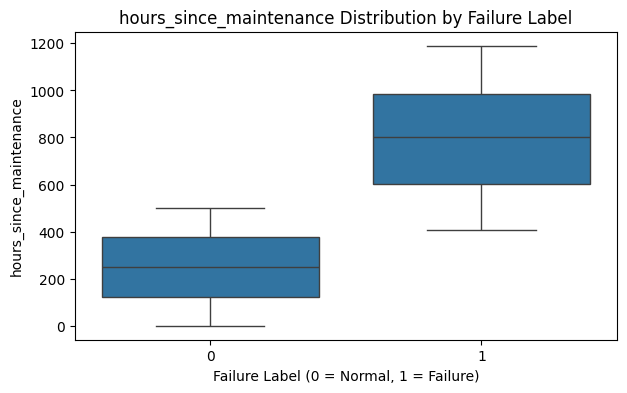

In [20]:
sensor_cols = [
    'vibration_mms',
    'temperature_c',
    'pressure_psi',
    'rpm',
    'oil_flow_rate',
    'current_draw_a',
    'hours_since_maintenance'
]

for col in sensor_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x='failure_label', y=col)
    plt.title(f'{col} Distribution by Failure Label')
    plt.xlabel('Failure Label (0 = Normal, 1 = Failure)')
    plt.ylabel(col)
    plt.show()

In [21]:

#Failure count by equipment type
failure_by_type = df.groupby('equipment_type')['failure_label'].agg(['count', 'sum', 'mean'])

failure_by_type = failure_by_type.rename(columns={
    'count': 'total_records',
    'sum': 'failure_count',
    'mean': 'failure_rate'
})

failure_by_type['failure_rate_percent'] = failure_by_type['failure_rate'] * 100

failure_by_type

,total_records,failure_count,failure_rate,failure_rate_percent
equipment_type,,,,
Compressor,226,31,0.137168,13.716814
Generator,479,68,0.141962,14.196242
Pipeline,421,43,0.102138,10.213777
Pump,75,14,0.186667,18.666667
Valve,349,44,0.126074,12.607450


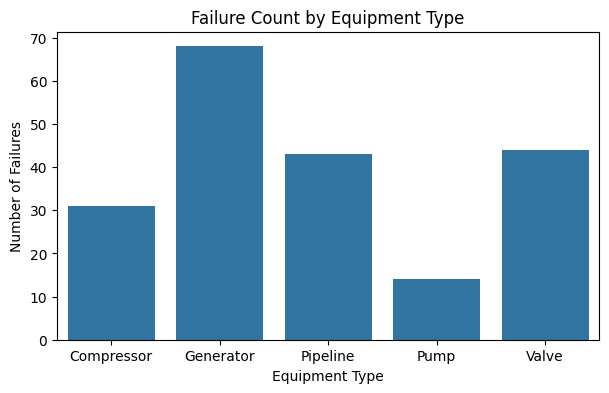

In [22]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=failure_by_type.reset_index(),
    x='equipment_type',
    y='failure_count'
)

plt.title('Failure Count by Equipment Type')
plt.xlabel('Equipment Type')
plt.ylabel('Number of Failures')
plt.show()

DATA PREPROCESSING 

In [23]:
#3.1 Handling Missing Values
# 	#For numeric columns, impute using the column median (more robust than mean for skewed data)

In [24]:
#check of missing values 
df.isnull().sum()

timestamp                   0
equipment_id                0
equipment_type              0
vibration_mms              48
temperature_c              42
pressure_psi               46
rpm                         0
oil_flow_rate              44
current_draw_a              0
hours_since_maintenance     0
failure_label               0
dtype: int64

In [25]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

C:\Users\USER\AppData\Local\Temp\ipykernel_16696\568227309.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [26]:
# Count total missing values before imputation
total_missing_before = df.isnull().sum().sum()


In [27]:
# Impute numeric columns with median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)


In [28]:
# Check missing values after imputation
missing_after = df.isnull().sum()
total_missing_after = df.isnull().sum().sum()
print("\nMissing values after imputation:")
print(missing_after[missing_after > 0])

print("\nTotal missing values before imputation:", total_missing_before)
print("Total missing values after imputation:", total_missing_after)
print("Total values handled:", total_missing_before - total_missing_after)



Missing values after imputation:
Series([], dtype: int64)

Total missing values before imputation: 180
Total missing values after imputation: 0
Total values handled: 180


#HANDLING OUTLIERS USING IGR METHOD 

In [29]:
# Sensor columns only
sensor_cols = [
    'vibration_mms',
    'temperature_c',
    'pressure_psi',
    'rpm',
    'oil_flow_rate',
    'current_draw_a',
    'hours_since_maintenance'
]

In [30]:
# Create an empty list to store outlier results
outlier_summary = []

for col in sensor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        'column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': outliers.shape[0],
        'outlier_percentage': (outliers.shape[0] / df.shape[0]) * 100
    })

In [31]:
# Convert summary to DataFrame
outlier_summary_df = pd.DataFrame(outlier_summary)  #SHOWS RATE OF OUTLIERS IN EACH COLUMNS

outlier_summary_df

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,vibration_mms,3.11625,4.379,1.26275,1.222125,6.273125,193,12.451613
1,temperature_c,72.57000,80.335,7.76500,60.922500,91.982500,197,12.709677
2,pressure_psi,431.10000,461.740,30.64000,385.140000,507.700000,194,12.516129
3,rpm,1444.62500,1525.700,81.07500,1323.012500,1647.312500,201,12.967742
4,oil_flow_rate,109.82250,125.305,15.48250,86.598750,148.528750,184,11.870968
5,current_draw_a,43.31000,48.250,4.94000,35.900000,55.660000,202,13.032258
6,hours_since_maintenance,140.00000,423.000,283.00000,-284.500000,847.500000,78,5.032258


### Outlier Handling Decision

The IQR method was used to identify potential outliers in the sensor columns. Several sensor variables contained extreme values, especially vibration, temperature, RPM, current draw, oil flow rate, and hours since maintenance.

However, because this project focuses on equipment failure and anomaly detection, these extreme values may represent meaningful abnormal operating conditions rather than data errors. For example, unusually high vibration, high temperature, high current draw, low oil flow rate, or long hours since maintenance may indicate equipment stress or possible failure.

Therefore, the outliers were not removed at this stage. They were retained because they may contain useful failure signals for both KMeans anomaly detection and Random Forest classification.

In [32]:
#3.3 Feature Engineering
# First, make a copy so your original dataframe is preserved
df_fe = df.copy()
# Convert timestamp column to datetime format
df_fe['timestamp'] = pd.to_datetime(df_fe['timestamp'])

# Sort data by equipment_id and timestamp
# This is important before calculating rolling statistics
df_fe = df_fe.sort_values(by=['equipment_id', 'timestamp'])


In [33]:
# Extract time-based features
df_fe['hour'] = df_fe['timestamp'].dt.hour
df_fe['day_of_week'] = df_fe['timestamp'].dt.dayofweek
df_fe['month'] = df_fe['timestamp'].dt.month


In [34]:
# Create rolling mean and rolling standard deviation for vibration per equipment
df_fe['vibration_rolling_mean_5'] = (
    df_fe.groupby('equipment_id')['vibration_mms']
    .rolling(window=5, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df_fe['vibration_rolling_std_5'] = (
    df_fe.groupby('equipment_id')['vibration_mms']
    .rolling(window=5, min_periods=1)
    .std()
    .reset_index(level=0, drop=True)
)

In [35]:
# Create rolling mean and rolling standard deviation for temperature per equipment
df_fe['temperature_rolling_mean_5'] = (
    df_fe.groupby('equipment_id')['temperature_c']
    .rolling(window=5, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df_fe['temperature_rolling_std_5'] = (
    df_fe.groupby('equipment_id')['temperature_c']
    .rolling(window=5, min_periods=1)
    .std()
    .reset_index(level=0, drop=True)
)

In [36]:
# Rolling standard deviation gives NaN for the first reading of each equipment_id
# Fill those NaN values with 0 because there is no previous variation yet
rolling_std_cols = [
    'vibration_rolling_std_5',
    'temperature_rolling_std_5'
]

df_fe[rolling_std_cols] = df_fe[rolling_std_cols].fillna(0)

# Check the newly created features
df_fe.head()

,timestamp,equipment_id,equipment_type,vibration_mms,temperature_c,pressure_psi,rpm,oil_flow_rate,current_draw_a,hours_since_maintenance,failure_label,hour,day_of_week,month,vibration_rolling_mean_5,vibration_rolling_std_5,temperature_rolling_mean_5,temperature_rolling_std_5
3,2023-01-02 18:00:00,EQ-001,Pipeline,13.300,101.85,339.79,819.9,62.76,67.30,524,1,18,0,1,13.300000,0.000000,101.8500,0.000000
42,2023-01-11 02:00:00,EQ-001,Pipeline,2.607,69.88,461.60,1552.4,115.23,49.91,134,0,2,2,1,7.953500,7.561093,85.8650,22.606204
68,2023-01-16 10:00:00,EQ-001,Pipeline,5.026,67.82,444.80,1467.2,118.20,49.11,81,0,10,0,1,6.977667,5.607300,79.8500,19.080380
74,2023-01-17 16:00:00,EQ-001,Pipeline,3.709,72.06,485.94,1576.5,109.82,42.26,84,0,16,1,1,6.160500,4.861302,77.9025,16.058589
79,2023-01-19 17:00:00,EQ-001,Pipeline,3.184,76.55,478.48,1570.7,119.71,45.42,356,0,17,3,1,5.565200,4.415439,77.6320,13.920293


ENCODING CATEGORICAL VARIABLE 

In [37]:
# Make a copy of the feature-engineered dataframe
df_model = df_fe.copy()

# One-hot encode equipment_type
df_model = pd.get_dummies(
    df_model,
    columns=['equipment_type'],
    drop_first=False
)

In [38]:
# Drop timestamp and equipment_id before modelling
df_model = df_model.drop(columns=['timestamp', 'equipment_id'])


In [39]:
# Separate features and target
X = df_model.drop(columns=['failure_label'])
y = df_model['failure_label']

print("Final feature columns:")
print(X.columns)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Final feature columns:
Index(['vibration_mms', 'temperature_c', 'pressure_psi', 'rpm',
       'oil_flow_rate', 'current_draw_a', 'hours_since_maintenance', 'hour',
       'day_of_week', 'month', 'vibration_rolling_mean_5',
       'vibration_rolling_std_5', 'temperature_rolling_mean_5',
       'temperature_rolling_std_5', 'equipment_type_Compressor',
       'equipment_type_Generator', 'equipment_type_Pipeline',
       'equipment_type_Pump', 'equipment_type_Valve'],
      dtype='str')

Feature matrix shape: (1550, 19)
Target shape: (1550,)


In [40]:
#Feature Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Separate features and target
X = df_model.drop(columns=['failure_label'])
y = df_model['failure_label']


In [41]:
# Train-test split first
# stratify=y keeps the same failure/normal ratio in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [42]:
# Identify numeric columns to scale
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Create scaler
scaler = StandardScaler()

In [43]:
# Fit scaler on training numeric columns only
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform test data using the scaler fitted on training data
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [44]:
# Check result
print("Training feature shape:", X_train_scaled.shape)
print("Testing feature shape:", X_test_scaled.shape)

X_train_scaled.head()

Training feature shape: (1240, 19)
Testing feature shape: (310, 19)


,vibration_mms,temperature_c,pressure_psi,rpm,oil_flow_rate,current_draw_a,hours_since_maintenance,hour,day_of_week,month,vibration_rolling_mean_5,vibration_rolling_std_5,temperature_rolling_mean_5,temperature_rolling_std_5,equipment_type_Compressor,equipment_type_Generator,equipment_type_Pipeline,equipment_type_Pump,equipment_type_Valve
1287,-0.137663,-0.960757,0.258088,0.649085,0.564908,-0.359204,-1.131343,23,1,10,-0.477774,-0.728473,-0.619670,-0.052520,False,True,False,False,False
393,-0.295350,1.876697,-2.435306,-1.651775,-1.856202,0.818003,1.087755,22,3,3,0.154590,0.744474,1.628568,1.337035,False,False,True,False,False
666,-0.361597,-0.581448,0.237457,0.145285,0.906168,-0.524440,-0.059619,11,3,6,-1.056711,-0.834570,-1.088652,-0.711793,False,True,False,False,False
1272,-0.295350,-0.422293,0.224129,0.478161,0.716740,-0.212875,-1.127140,9,5,10,-0.626230,-0.820032,-1.080571,-0.872306,False,False,True,False,False
495,0.111464,-0.273654,0.838687,-0.110629,0.715776,-0.538415,0.247188,13,2,4,0.653518,0.965647,0.090536,0.104320,False,False,False,False,True


In [45]:
# Check mean and standard deviation of scaled training numeric features
scaled_check = pd.DataFrame({
    'mean_after_scaling': X_train_scaled[numeric_cols].mean(),
    'std_after_scaling': X_train_scaled[numeric_cols].std()
})

scaled_check

,mean_after_scaling,std_after_scaling
vibration_mms,1.411058e-16,1.000403
temperature_c,5.952228e-16,1.000403
pressure_psi,-8.093884e-16,1.000403
rpm,-4.011128e-17,1.000403
oil_flow_rate,-5.601254e-16,1.000403
current_draw_a,-1.482685e-16,1.000403
hours_since_maintenance,-1.432546e-17,1.000403
vibration_rolling_mean_5,3.789084e-16,1.000403
vibration_rolling_std_5,7.305984e-17,1.000403
temperature_rolling_mean_5,1.396732e-15,1.000403


# 4. Phase 3: Model Building

In [46]:
#PREPARING OUR DATA FOR KMEANS MODEL
from sklearn.preprocessing import StandardScaler

# Separate features and label
X_kmeans = df_model.drop(columns=['failure_label'])
y_actual = df_model['failure_label']

# Scale all features for KMeans
scaler_kmeans = StandardScaler()
X_kmeans_scaled = scaler_kmeans.fit_transform(X_kmeans)

print("KMeans feature matrix shape:", X_kmeans_scaled.shape)

KMeans feature matrix shape: (1550, 19)


ELBOW METHOD FOR KMEANS 

In [47]:
#IMPORT KMEANS METHOD FROM SKLEARN 
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [48]:

inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_kmeans_scaled)
    inertia_values.append(kmeans.inertia_)

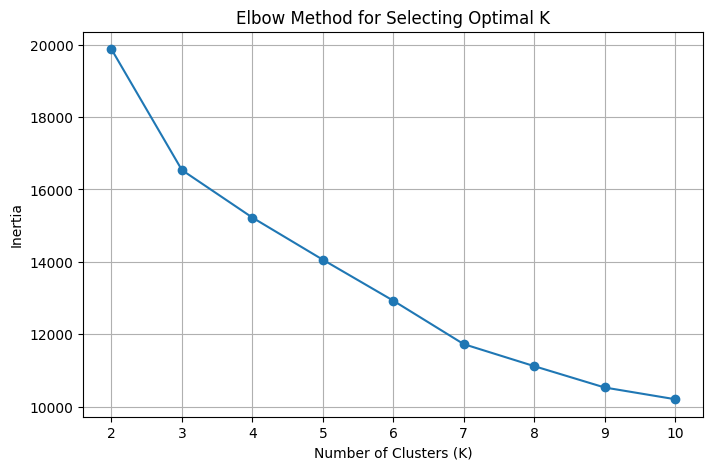

In [49]:
# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method for Selecting Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [50]:
#FIT KMEANS =3 as recommended 
from sklearn.cluster import KMeans

In [51]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_kmeans_scaled)

In [52]:
# Add cluster labels to a copy of the dataframe for analysis
df_kmeans_results = df_model.copy()
df_kmeans_results['cluster'] = kmeans_labels

# Check cluster sizes
df_kmeans_results['cluster'].value_counts()

cluster
0    869
2    481
1    200
Name: count, dtype: int64

In [53]:
#calculate distance from each point to each cluster center 
distances = kmeans.transform(X_kmeans_scaled)

In [54]:
# Select the shortest distance for each row
nearest_cluster_distance = np.min(distances, axis=1)

In [55]:
# Add anomaly score to results dataframe
df_kmeans_results['anomaly_score'] = nearest_cluster_distance


In [56]:
# Check summary statistics of anomaly scores
df_kmeans_results['anomaly_score'].describe()

count    1550.000000
mean        3.190370
std         0.699951
min         2.002907
25%         2.749416
50%         3.051020
75%         3.449593
max         8.662172
Name: anomaly_score, dtype: float64

In [57]:
#flag anomaly using 95th percentile 

In [58]:
threshold_95 = df_kmeans_results['anomaly_score'].quantile(0.95)

df_kmeans_results['kmeans_anomaly'] = (
    df_kmeans_results['anomaly_score'] > threshold_95
).astype(int)

print("95th percentile anomaly threshold:", threshold_95)

print("\nAnomaly counts:")
print(df_kmeans_results['kmeans_anomaly'].value_counts())

95th percentile anomaly threshold: 4.893509374410139

Anomaly counts:
kmeans_anomaly
0    1472
1      78
Name: count, dtype: int64


#KMeans has identified 78 records that are farthest from their nearest cluster center. These records do not fit well into the main operating patterns learned by the model.

#These 78 records represent unusual equipment behavior and should be treated as potential anomaly cases.

In [59]:
#EVALUATE KMEANS ANOMALIES AGAINST ACTUAL FAILURE LABEL
y_true = df_kmeans_results['failure_label']
y_pred = df_kmeans_results['kmeans_anomaly']


In [60]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
y_true = df_kmeans_results['failure_label']
y_pred = df_kmeans_results['kmeans_anomaly']
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Confusion Matrix:
[[1301   49]
 [ 171   29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1350
           1       0.37      0.14      0.21       200

    accuracy                           0.86      1550
   macro avg       0.63      0.55      0.57      1550
weighted avg       0.82      0.86      0.83      1550

Precision: 0.3717948717948718
Recall: 0.145
F1 Score: 0.20863309352517986


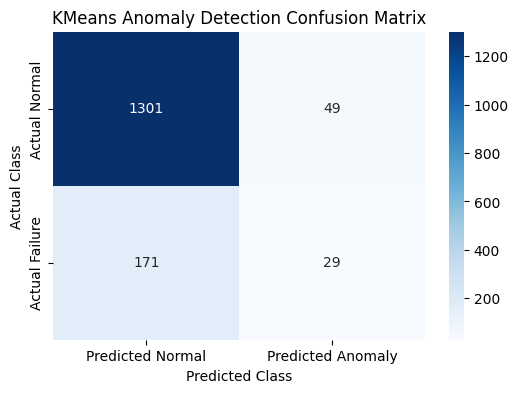

In [61]:
#CONFUSION MATRIX PLOT
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Anomaly'],
    yticklabels=['Actual Normal', 'Actual Failure']
)

plt.title('KMeans Anomaly Detection Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

The KMeans model flagged 78 records as anomalies using the 95th percentile anomaly-score threshold. Out of 200 actual failure records, only 29 were correctly identified, while 171 failures were missed. This gives a low failure recall, showing that KMeans did not capture most failure cases at this threshold. However, the model correctly classified 1,301 normal records and produced 49 false alarms. This suggests that KMeans can identify some unusual operating patterns, but it is not sufficient as a standalone failure detection model. Since KMeans is unsupervised and does not use failure labels during training, its performance should be interpreted as anomaly-screening rather than direct failure classification.

In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

thresholds = [0.90, 0.95, 0.99]

results = []

y_true = df_kmeans_results['failure_label']

for q in thresholds:
    threshold_value = df_kmeans_results['anomaly_score'].quantile(q)
    
    y_pred = (
        df_kmeans_results['anomaly_score'] > threshold_value
    ).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    
    tn, fp, fn, tp = cm.ravel()
    
    results.append({
        'threshold_percentile': q,
        'threshold_value': threshold_value,
        'predicted_anomalies': y_pred.sum(),
        'true_normal': tn,
        'false_alarm': fp,
        'missed_failure': fn,
        'caught_failure': tp,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold_percentile,threshold_value,predicted_anomalies,true_normal,false_alarm,missed_failure,caught_failure,precision,recall,f1_score
0,0.90,3.967750,155,1276,74,119,81,0.522581,0.405,0.456338
1,0.95,4.893509,78,1301,49,171,29,0.371795,0.145,0.208633
2,0.99,5.422174,16,1346,4,188,12,0.750000,0.060,0.111111


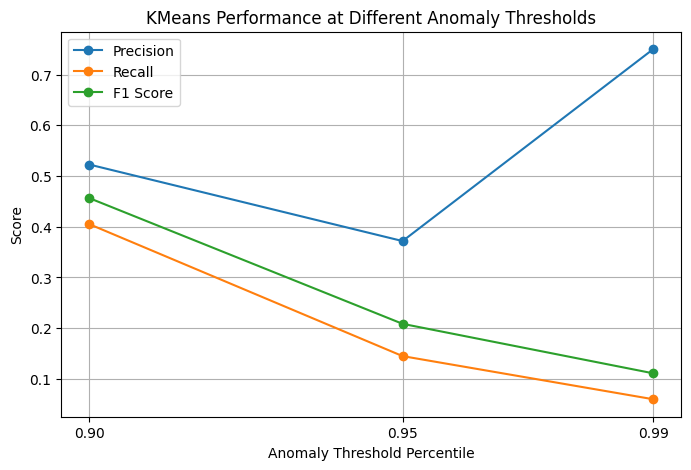

In [63]:

# PLOT PRECISION, RECALL, AND F1 BY THRESHOLD


plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results['threshold_percentile'],
    threshold_results['precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_results['threshold_percentile'],
    threshold_results['recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_results['threshold_percentile'],
    threshold_results['f1_score'],
    marker='o',
    label='F1 Score'
)

plt.title('KMeans Performance at Different Anomaly Thresholds')
plt.xlabel('Anomaly Threshold Percentile')
plt.ylabel('Score')
plt.xticks(threshold_results['threshold_percentile'])
plt.legend()
plt.grid(True)
plt.show()

The 90th percentile threshold was selected because it produced the best balance between precision and recall. Although it flags more anomalies than stricter thresholds, it catches more actual failure cases, which is important in predictive maintenance where missing a real failure can be costly

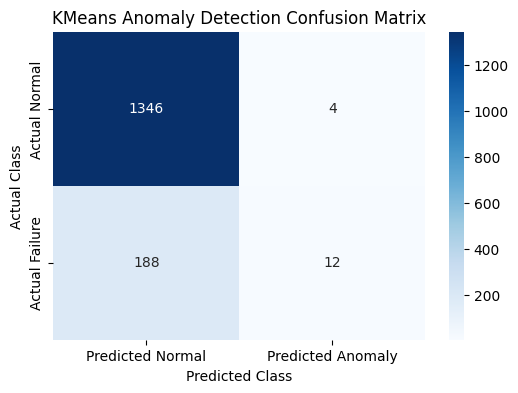

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Anomaly'],
    yticklabels=['Actual Normal', 'Actual Failure']
)

plt.title('KMeans Anomaly Detection Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()